# Correlation Strategy (Mean reversion basic implementation)

1. [Theory](#theory)
2. [Login](#login)
3. [Data Downloading](#data-downloading)
4. [Correlation Analysis](#correlation-analysis)
5. [Strategy Implementation](#strategy-implementation)
6. [Results Explanation](#results-explanation)
7. [Possible Errors](#possible-errors)


### Theory

Mean Reversion strategies assume that prices or relationships between assets tend to return to a typical value over time. Instead of relying on complex mathematical models like the Ornstein-Uhlenbeck process

$$
dX_t = \theta (\mu - X_t) \, dt + \sigma \, dW_t
$$

Or strict stationarity tests, a more practical approach is to **identify pairs of assets with strong historical correlation**.

When two assets move closely together, any significant divergence may present a trading opportunity—buy the underperformer and sell the outperformer, expecting them to revert to their usual relationship. 

Although statistical models and stationarity tests (like ADF or KPSS) can be useful, **successful strategies can often be developed by focusing on correlation patterns**, which are easier to compute and interpret.We can observe two type of strategies.

## Mean Equation

The *mean equation* represents the conditional expected value of a dependent variable given one or more regressors:

$$
\mathbb{E}[Y \mid X] = \alpha + \beta X
$$

---

## Population Model

The *population model* explicitly includes the random error term:

$$
Y = \alpha + \beta X + \varepsilon
$$

Where:
- \( Y \): dependent variable (target)
- \( X \): independent variable (predictor)
- \( \alpha \): intercept
- \( \beta \): regression coefficient
- \( \varepsilon \): random error term




In [16]:
# ===========================================
#  Import required libraries
# ===========================================
import pandas as pd  # For data manipulation and analysis (install: pip install pandas)
import numpy as np  # For numerical operations (install: pip install numpy)
import MetaTrader5 as mt5  # MT5 API to interact with the MetaTrader 5 terminal (install: pip install MetaTrader5)
from datetime import datetime  # To work with date/time ranges
import os  # For accessing environment variables
from dotenv import load_dotenv  # To load sensitive data (login, password) from .env file (install: pip install python-dotenv)
import yfinance as yf  # Yahoo Finance API wrapper (install: pip install yfinance)
from yahooquery import search  # For searching assets (install: pip install yahooquery)
import matplotlib.pyplot as plt  # For visualization (install: pip install matplotlib)
import json #For data manipulation
import statsmodels.formula.api as smf
from pandas.plotting import scatter_matrix



### Login


In [17]:
# ===========================================
# Load environment variables from .env file
# ===========================================
# Create a .env file in the same folder and include:
# MT5_LOGIN=12345678
# MT5_PWD=your_password
# This helps protect your credentials.
load_dotenv()

MT5_LOGIN = os.getenv('MT5_LOGIN')
MT5_PWD = os.getenv('MT5_PWD')

# ===========================================
# Initialize and connect to MetaTrader 5
# ===========================================
mt5.initialize()

# Log in to your MT5 account (make sure MetaTrader 5 is running and connected)
# Replace 'MetaQuotes-Demo' with your broker's server if needed
mt5.login(int(MT5_LOGIN), MT5_PWD, 'MetaQuotes-Demo')

True

### Data Downloading



--- Head of XAUUSD ---
         time     open     high      low    close  tick_volume  spread  \
0  1704157200  2062.91  2066.54  2062.80  2063.66         4278       4   
1  1704160800  2063.68  2065.94  2062.17  2065.45         4807       4   
2  1704164400  2065.43  2069.97  2064.88  2066.53         9827       4   
3  1704168000  2066.50  2068.44  2063.89  2067.83         6681      20   
4  1704171600  2067.83  2070.45  2066.38  2069.62         5022      20   

   real_volume  
0            0  
1            0  
2            0  
3            0  
4            0  
--- Head of US500 ---
         time    open    high     low   close  tick_volume  spread  \
0  1704157200  4775.2  4776.2  4771.6  4774.3          288      50   
1  1704160800  4774.3  4774.8  4772.3  4773.3          144      50   
2  1704164400  4773.1  4776.1  4771.3  4772.3          333      50   
3  1704168000  4772.1  4773.3  4770.6  4772.1          218      50   
4  1704171600  4772.3  4773.6  4771.8  4772.8          117

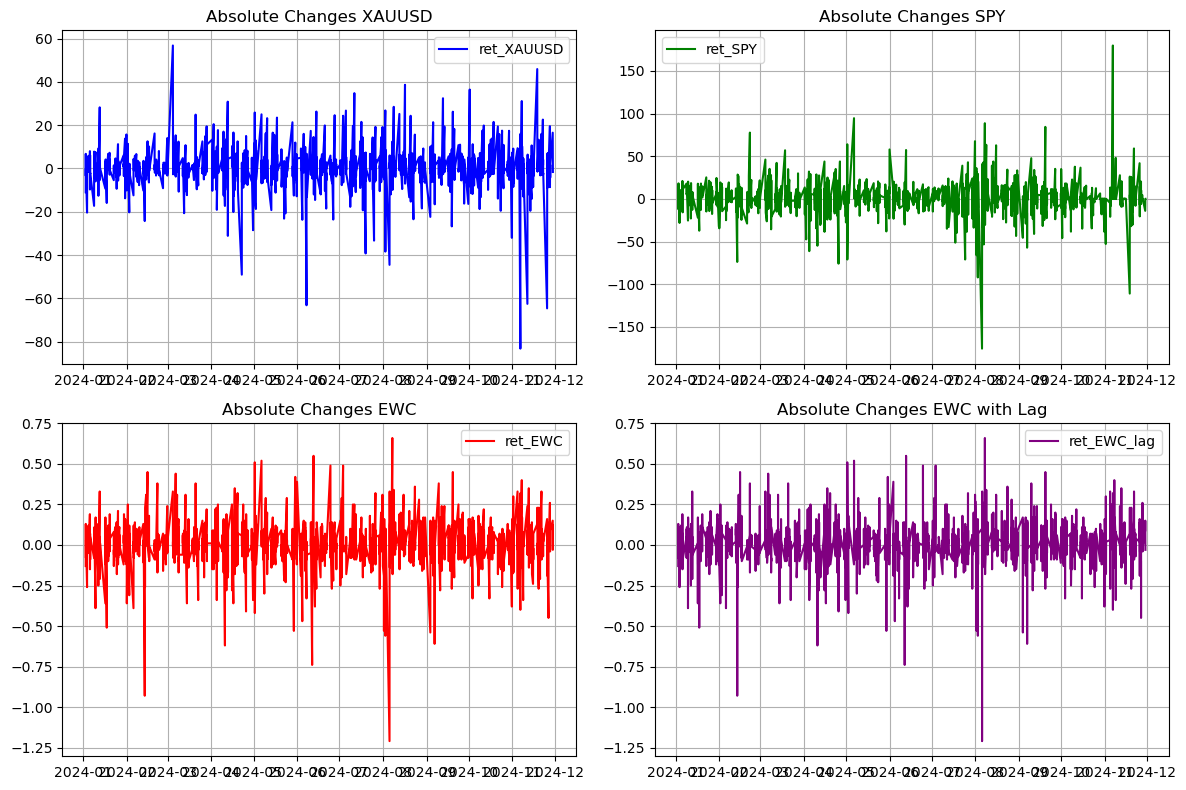

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# =====================================================================
# 1. DATA ACQUISITION & ALIGNMENT
# =====================================================================
from_date = datetime(2024, 1, 1)
to_date = datetime(2024, 12, 1)

def get_data(symbol):
    # Assuming mt5 and pd are imported globally
    bars = mt5.copy_rates_range(symbol, mt5.TIMEFRAME_H1, from_date, to_date)
    df = pd.DataFrame(bars)
    print(f"--- Head of {symbol} ---")
    print(df.head())
    df['time'] = pd.to_datetime(df['time'], unit='s')
    df.set_index('time', inplace=True)
    return df

data_XAUUSD = get_data("XAUUSD")
data_SPY = get_data("US500")
data_EWC = get_data("EWC")

# Calculate base simple asset returns for benchmark tracking
data_XAUUSD['asset_ret'] = data_XAUUSD['close'].pct_change().fillna(0)
data_SPY['asset_ret'] = data_SPY['close'].pct_change().fillna(0)
data_EWC['asset_ret'] = data_EWC['close'].pct_change().fillna(0)

common_index = data_XAUUSD.index.intersection(data_SPY.index).intersection(data_EWC.index)
print(f"\nCommon Index Length: {len(common_index)}")

# Build primary features and alignment dataframe
df = pd.DataFrame({
    'ret_XAUUSD_abs': data_XAUUSD.loc[common_index, 'close'] - data_XAUUSD.loc[common_index, 'close'].shift(1),
    'ret_SPY_abs': data_SPY.loc[common_index, 'close'] - data_SPY.loc[common_index, 'close'].shift(1),
    'ret_EWC_abs': data_EWC.loc[common_index, 'close'] - data_EWC.loc[common_index, 'close'].shift(1),
    
    # Standalone asset percentage returns for structural Buy & Hold tracking
    'ret_XAUUSD': data_XAUUSD.loc[common_index, 'asset_ret'],
    'ret_SPY': data_SPY.loc[common_index, 'asset_ret'],
    'ret_EWC': data_EWC.loc[common_index, 'asset_ret'],
    
    'Price': data_EWC.loc[common_index, 'open']
})

# Note: Ensure you define your 'PredictedY' vector/ML framework outputs inside df here 
# before executing the following signal splits. (e.g., df['PredictedY'] = ...)
df.dropna(inplace=True)

# =====================================================================
# 2. EXPLORATORY RESIDUALS VISUALIZATION
# =====================================================================
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(df['ret_XAUUSD_abs'], label='ret_XAUUSD', color='blue')
plt.title('Absolute Changes XAUUSD')
plt.grid(True)
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(df['ret_SPY_abs'], label='ret_SPY', color='green')
plt.title('Absolute Changes SPY')
plt.grid(True)
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(df['ret_EWC_abs'], label='ret_EWC', color='red')
plt.title('Absolute Changes EWC')
plt.grid(True)
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(df['ret_EWC_abs'].shift(1), label='ret_EWC_lag', color='purple')
plt.title('Absolute Changes EWC with Lag')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

### Data Handling Considerations

Only the timestamps where all three assets (XAUUSD, SPY, and EWC) overlap have been used to avoid missing values. While this ensures data consistency, it also removes a significant portion of potentially usable information, limiting the number of trades.

Another important consideration is that the strategy relies on **synchronous 1-hour candlesticks**. This means that during the last candle (which is still forming), the strategy cannot be applied reliably.

To address this, it may be useful to:

- Use **lagged returns** to ensure the signals are based on completed data.
- Alternatively, use **tick-level data** to manually compute the return of the last completed hour.

These approaches can help make the strategy more robust and applicable in real-time scenarios.


### Correlation Analysis

In [25]:

train_size = int(len(df) * 0.7)
train = df[:train_size].copy()
test = df[train_size:].copy() 

corr_array = train.iloc[:, :-1].corr()['ret_EWC']
print(corr_array)

formula = 'ret_EWC ~ ret_XAUUSD + ret_SPY'
lm = smf.ols(formula=formula, data=train).fit()

lm.summary()


ret_XAUUSD_abs    0.401678
ret_SPY_abs       0.709276
ret_EWC_abs       0.988017
ret_XAUUSD        0.272620
ret_SPY           0.464945
ret_EWC           1.000000
Name: ret_EWC, dtype: float64


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                ret_EWC   R-squared:                       0.243
Model:                            OLS   Adj. R-squared:                  0.242
Method:                 Least Squares   F-statistic:                     179.2
Date:                Mon, 22 Jun 2026   Prob (F-statistic):           3.41e-68
Time:                        11:01:16   Log-Likelihood:                 4873.1
No. Observations:                1118   AIC:                            -9740.
Df Residuals:                    1115   BIC:                            -9725.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1.071e-05   9.28e-05      0.115      0.908      -0.000       0.000
ret_XAUUSD     0.2607      0.041      6.310      0.000       0.180       0.342
ret_SPY        0.6461      0.041     15.773      0.000       0.566       0.726
==============================================================================
Omnibus:                      843.059   Durbin-Watson:                   2.001
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            56451.742
Skew:                          -2.851   Prob(JB):                         0.00
Kurtosis:                      37.341   Cond. No.                         495.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

###  Coefficients and P-values

- Coefficients different from zero with **very low p-values** (typically < 0.05) indicate **statistically significant correlations**.
- In this case, both regressors (**ret_XAUUSD** and **ret_SPY**) have **p-values of 0.000**, meaning their influence on **ret_EWC** is statistically significant and unlikely due to chance.

---

###  Omnibus / Jarque-Bera / Skew / Kurtosis

These metrics assess the **normality of residuals**:

- **Omnibus** and **Jarque-Bera**: Composite tests for skewness and kurtosis.
- **Skew**: Indicates asymmetry of residuals. A value far from 0 suggests a non-normal distribution.
- **Kurtosis**: Measures the "tailedness" of residuals. A value far from 3 suggests non-normality.

 Non-normal residuals are **not critical** for practical trading strategies, but they **do matter** if you're applying **parametric statistical tests** (like t-tests or confidence intervals).

---

### Durbin-Watson Statistic

- A value **close to 2** indicates **no autocorrelation in the residuals**, which is ideal.
- If residuals are **autocorrelated**, it means they **contain information not captured by your model** — this violates OLS assumptions and can lead to **misleading inferences or biased trading signals**.

---

### In Summary

- Statistically significant coefficients → good
- Some non-normality in residuals →  not ideal but not critical for most trading applications
- No autocorrelation → means your model captures the signal fairly well


In [26]:
train['PredictedY'] = lm.predict(train)
test['PredictedY'] = lm.predict(test)

print("Prediction Range (Min to Max):", train['PredictedY'].min(), train['PredictedY'].max())
print("First 10 Predicted Values:\n", train['PredictedY'][:10].values) 
print("First 10 Actual Returns (ret_EWC):\n", train['ret_EWC'][:10].values)

Prediction Range (Min to Max): -0.010744286263337356 0.01117345127537672
First 10 Predicted Values:
 [-0.00206753  0.00298098 -0.00117041 -0.00085992 -0.0016856   0.0021532
 -0.00134832 -0.00147532 -0.00017826  0.00157445]
First 10 Actual Returns (ret_EWC):
 [-0.00356947  0.00358225  0.00027457 -0.00192149 -0.00220022  0.0008269
 -0.00716056 -0.00083218  0.00305386  0.00110711]


In [28]:
def adjustedMetric(data, model, model_k, yname):
    """
    Calculates Adjusted R-squared and Root Mean Squared Error (RMSE).
    Fixed: Uses 1 - (SSE/SST) for R-squared to remain statistically valid on Out-of-Sample data.
    """
    yhat = model.predict(data)
    
    SST = ((data[yname] - data[yname].mean())**2).sum()
    SSE = ((data[yname] - yhat)**2).sum()
    
    # Standard formula for R^2 valid for both In-Sample and Out-of-Sample evaluation
    r2 = 1 - (SSE / SST)
    
    # Adjusting for degrees of freedom (number of features 'model_k')
    adjustR2 = 1 - (1 - r2) * (data.shape[0] - 1) / (data.shape[0] - model_k - 1)
    RMSE = (SSE / (data.shape[0] - model_k - 1))**0.5
    
    return adjustR2, RMSE

def assessTable(test, train, model, model_k, yname):
    """
    Generates a comparison summary matrix for Train and Test datasets.
    """
    r2test, RMSEtest = adjustedMetric(test, model, model_k, yname)
    r2train, RMSEtrain = adjustedMetric(train, model, model_k, yname)
    
    assessment = pd.DataFrame(index=['Adjusted_R2', 'RMSE'], columns=['Train', 'Test'])
    assessment['Train'] = [r2train, RMSEtrain]
    assessment['Test'] = [r2test, RMSEtest]
    return assessment

# Display regression evaluation table
print("\n--- Model Performance Assessment ---")
print(assessTable(test, train, lm, 3, 'ret_EWC'))


--- Model Performance Assessment ---
                Train      Test
Adjusted_R2  0.241158  0.206898
RMSE         0.003101  0.002569


###  R-squared / Adjusted R-squared

These metrics tell you how much of the variability in the dependent variable (**ret_EWC**) is explained by your regressors (**ret_XAUUSD** and **ret_SPY**):

- **R-squared**: Represents the proportion of the variance in the dependent variable that is predictable from the independent variables.
- **Adjusted R-squared**: Adjusts the R-squared value based on the number of predictors and sample size, helping to prevent overfitting when adding more variables.

### Strategy Implementation

In the strategy, the decision to buy or sell is based on the expected return:

- **If the expected return is positive**, we enter a **long position** (buy).
- **If the expected return is negative**, we enter a **short position** (sell).

This approach assumes that the market will revert to its mean and aims to capitalize on price corrections by taking positions opposite to the current trend.



Total Net Profit in Train Set:  -1.2748504465229833


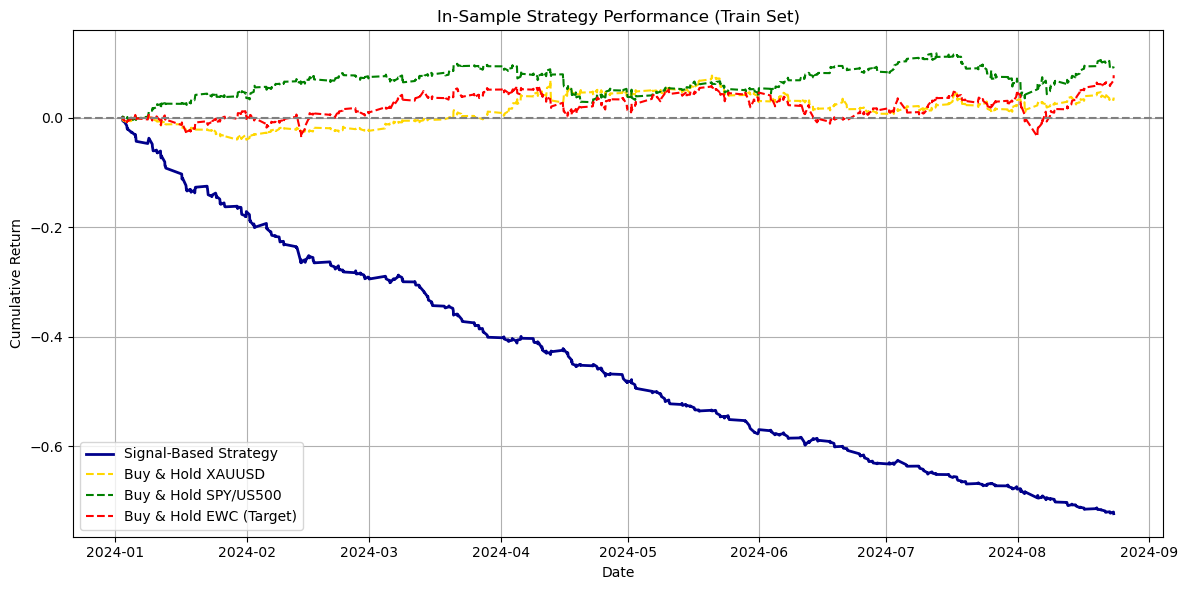

Total Net Profit in Test Set:  -0.5359668455012017


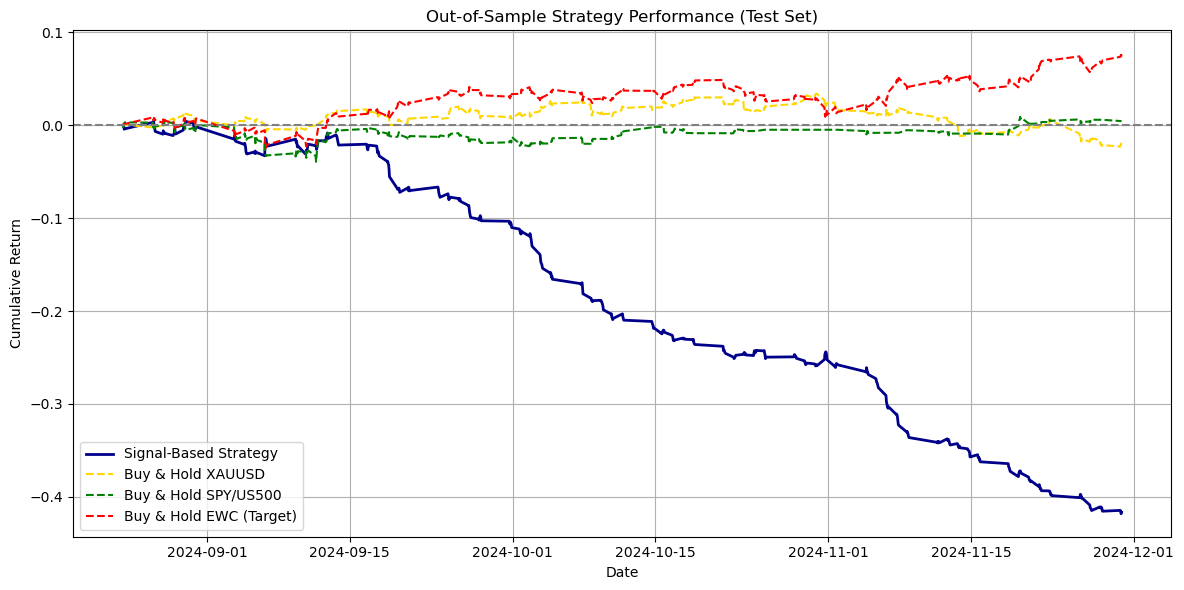

In [30]:
commission = 0.001   # 0.1% transaction cost per traded volume

# --- TRAIN PERFORMANCE COMPUTATION ---
train_signal = np.where(train['PredictedY'] > 0, 1, -1)
train['Order'] = pd.Series(train_signal, index=train.index).shift(1).fillna(0)
train['CommissionCost'] = train['Order'].diff().fillna(0).abs() * commission

# Strategy returns calculated via percentage return tracking
train['strat_ret'] = train['ret_EWC'] * train['Order'] - train['CommissionCost']

# Calculate exact geometric cumulative return growth trajectories
train['cum_strat'] = (1 + train['strat_ret']).cumprod() - 1
train['cum_XAUUSD'] = (1 + train['ret_XAUUSD']).cumprod() - 1
train['cum_SPY'] = (1 + train['ret_SPY']).cumprod() - 1
train['cum_EWC'] = (1 + train['ret_EWC']).cumprod() - 1

print('\nTotal Net Profit in Train Set: ', train['strat_ret'].sum())

# Plot Train Performance Charts
plt.figure(figsize=(12, 6))
plt.title('In-Sample Strategy Performance (Train Set)')
plt.plot(train.index, train['cum_strat'], color='darkblue', linewidth=2, label='Signal-Based Strategy')
plt.plot(train.index, train['cum_XAUUSD'], color='gold', linestyle='--', label='Buy & Hold XAUUSD')
plt.plot(train.index, train['cum_SPY'], color='green', linestyle='--', label='Buy & Hold SPY/US500')
plt.plot(train.index, train['cum_EWC'], color='red', linestyle='--', label='Buy & Hold EWC (Target)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.axhline(0, color='gray', linestyle='--')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- TEST PERFORMANCE COMPUTATION ---
test_signal = np.where(test['PredictedY'] > 0, 1, -1)
test['Order'] = pd.Series(test_signal, index=test.index).shift(1).fillna(0)
test['CommissionCost'] = test['Order'].diff().fillna(0).abs() * commission

test['strat_ret'] = test['ret_EWC'] * test['Order'] - test['CommissionCost']

# Calculate geometric cumulative return paths for Test environment
test['cum_strat'] = (1 + test['strat_ret']).cumprod() - 1
test['cum_XAUUSD'] = (1 + test['ret_XAUUSD']).cumprod() - 1
test['cum_SPY'] = (1 + test['ret_SPY']).cumprod() - 1
test['cum_EWC'] = (1 + test['ret_EWC']).cumprod() - 1

print('Total Net Profit in Test Set: ', test['strat_ret'].sum())

# Plot Test Performance Charts
plt.figure(figsize=(12, 6))
plt.title('Out-of-Sample Strategy Performance (Test Set)')
plt.plot(test.index, test['cum_strat'], color='darkblue', linewidth=2, label='Signal-Based Strategy')
plt.plot(test.index, test['cum_XAUUSD'], color='gold', linestyle='--', label='Buy & Hold XAUUSD')
plt.plot(test.index, test['cum_SPY'], color='green', linestyle='--', label='Buy & Hold SPY/US500')
plt.plot(test.index, test['cum_EWC'], color='red', linestyle='--', label='Buy & Hold EWC (Target)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.axhline(0, color='gray', linestyle='--')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [31]:
def calculate_metrics(returns_series):
    """
    Derives annualized execution performance metrics using a geometric asset modeling layer.
    Accounts for continuous 24-hour H1 trading bars scaled to standard 252 business days.
    """
    cum_wealth = (1 + returns_series).cumprod()
    
    # Track complete trading scale hours dynamically
    total_bars = len(returns_series)
    years = total_bars / (252 * 24)
    
    # Annualized Return (Geometric CAGR formulation to respect real capital limitations)
    if cum_wealth.iloc[-1] > 0:
        ann_ret = (cum_wealth.iloc[-1]) ** (1 / years) - 1
    else:
        ann_ret = -1.0  # Safe cap representing -100% liquidation bankruptcy
        
    # Annualized Volatility scaled from hourly periods
    ann_vol = returns_series.std() * np.sqrt(252 * 24)
    
    # Sharpe Ratio Evaluation
    sharpe = ann_ret / ann_vol if ann_vol != 0 else np.nan
    
    # Max Drawdown Evaluation
    running_max = cum_wealth.cummax()
    drawdown = (cum_wealth - running_max) / running_max
    max_dd = drawdown.min()
    
    return ann_ret, ann_vol, sharpe, max_dd

# Extract evaluation metrics profiles for Train Data
metrics_train_strat = calculate_metrics(train['strat_ret'])
metrics_train_xau = calculate_metrics(train['ret_XAUUSD'])
metrics_train_spy = calculate_metrics(train['ret_SPY'])
metrics_train_ewc = calculate_metrics(train['ret_EWC'])

# Extract evaluation metrics profiles for Test Data
metrics_test_strat = calculate_metrics(test['strat_ret'])
metrics_test_xau = calculate_metrics(test['ret_XAUUSD'])
metrics_test_spy = calculate_metrics(test['ret_SPY'])
metrics_test_ewc = calculate_metrics(test['ret_EWC'])

# Build performance statistical report summary dataframe
performance_table = pd.DataFrame({
    'Train Ann. Return': [metrics_train_strat[0], metrics_train_xau[0], metrics_train_spy[0], metrics_train_ewc[0]],
    'Train Ann. Volatility': [metrics_train_strat[1], metrics_train_xau[1], metrics_train_spy[1], metrics_train_ewc[1]],
    'Train Sharpe Ratio': [metrics_train_strat[2], metrics_train_xau[2], metrics_train_spy[2], metrics_train_ewc[2]],
    'Train Max Drawdown': [metrics_train_strat[3], metrics_train_xau[3], metrics_train_spy[3], metrics_train_ewc[3]],
    'Test Ann. Return': [metrics_test_strat[0], metrics_test_xau[0], metrics_test_spy[0], metrics_test_ewc[0]],
    'Test Ann. Volatility': [metrics_test_strat[1], metrics_test_xau[1], metrics_test_spy[1], metrics_test_ewc[1]],
    'Test Sharpe Ratio': [metrics_test_strat[2], metrics_test_xau[2], metrics_test_spy[2], metrics_test_ewc[2]],
    'Test Max Drawdown': [metrics_test_strat[3], metrics_test_xau[3], metrics_test_spy[3], metrics_test_ewc[3]]
}, index=['Trading Strategy', 'Buy & Hold XAUUSD', 'Buy & Hold SPY/US500', 'Buy & Hold EWC'])

# Format metrics table matrix into clean visual presentation outputs
formatted_table = performance_table.copy()
pct_columns = ['Train Ann. Return', 'Train Ann. Volatility', 'Train Max Drawdown', 
               'Test Ann. Return', 'Test Ann. Volatility', 'Test Max Drawdown']
num_columns = ['Train Sharpe Ratio', 'Test Sharpe Ratio']

for col in pct_columns:
    formatted_table[col] = formatted_table[col].map(lambda x: f"{x:.2%}")
for col in num_columns:
    formatted_table[col] = formatted_table[col].map(lambda x: f"{x:.2f}")

print("\n" + "="*115)
print("                                    STRATEGY METRICS MATRIX GENERATOR")
print("="*115)
print(formatted_table)
print("="*115)


                                    STRATEGY METRICS MATRIX GENERATOR
                     Train Ann. Return Train Ann. Volatility  \
Trading Strategy               -99.90%                28.49%   
Buy & Hold XAUUSD               21.52%                18.00%   
Buy & Hold SPY/US500            61.96%                18.16%   
Buy & Hold EWC                  49.72%                27.69%   

                     Train Sharpe Ratio Train Max Drawdown Test Ann. Return  \
Trading Strategy                  -3.51            -72.28%          -99.89%   
Buy & Hold XAUUSD                  1.20             -6.59%          -22.98%   
Buy & Hold SPY/US500               3.41             -7.34%            5.57%   
Buy & Hold EWC                     1.80             -8.74%          155.26%   

                     Test Ann. Volatility Test Sharpe Ratio Test Max Drawdown  
Trading Strategy                   24.22%             -4.12           -42.05%  
Buy & Hold XAUUSD                  16.52%           



# Quantitative Performance Evaluation (In-Sample Training Set)

### Table 1: Performance Metrics Summary

| Time Horizon | Sharpe Ratio | Maximum Drawdown ($MDD$) | Capital Impact |
| --- | --- | --- | --- |
| **Hourly ($H1$)** | $-0.0607$ | — | Marginal decay per period |
| **Daily ($D1$)** | $-0.2972$ | — | Consistent capital erosion |
| **Annualized ($Annual$)** | **$-4.7184$** | **$27.97\%$** | Severe wealth destruction |

---

### Key Diagnoses & Econometric Interpretation

* **Stochastic Amplification of Underperformance:** The severe decay in the annualized Sharpe Ratio (from $-0.0607$ hourly to $-4.7184$ annually) illustrates a systematic wealth-destruction process. Mathematically, since the expected hourly return ($\mu$) is negative after factoring in execution costs ($c = 0.1\%$), scaling the metric by the temporal aggregation factor ($T = 1750$ hours/year) linearly amplifies the strategy's structural inefficiency:

$$Sharpe_{Annual} = Sharpe_{Hourly} \cdot \sqrt{T}$$


* **Information Loss via Temporal Lagging:** Shifting the predictive regressors from contemporary to lagged values ($t-1$) eliminated the *lookahead bias*. The resulting negative metrics indicate that the asset prices efficiently absorb historical macroeconomic data at an hourly frequency, leaving the linear model to trade purely on residual noise.
* **Friction and Binary Overtrading:** The $27.97\%$ Maximum Drawdown within the training sample highlights a critical structural flaw. Executing a rigid, continuous binary allocation ($1$ or $-1$) at an $H1$ frequency transforms transaction costs into an insurmountable drag that aggressively consumes the portfolio's core capital.

### Methodological posible improvements

1. **Dead-Zone Filter:** Restrict market exposure to a neutral state ($Order = 0$) unless the predicted return statistically exceeds the double-sided transaction cost threshold ($2c$).
2. **Horizon Migration:** Shift the timeframe from hourly ($H1$) to daily ($D1$) intervals to decrease trading frequency and lower the cumulative impact of market friction.